#  Group 2 Sentiment Analysis: New Sentiment approach

###  **DSBA 6165: AI & Deep Learning**
### Group Member: Paul Berlin, Anders Pierson, Roberto Panameno

## Proc Goal5

Attempting the lexicon model on a new dataset

## Uploading Training and Validation Dataset

In [ ]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Importing Dataset
datatot = pd.read_csv('/content/100ksentence_dataset_updated.csv')

In [ ]:
datatot.head(5)

,text
0,i feel rather funny ending with so many dupes ...
1,i feel surprised by the result
2,i am officially feeling festive
3,i suddenly found myself standing before this w...
4,i look at the meager pile of food i purchased ...


## Data Preprocessing

In [ ]:
import re
import pandas as pd

def clean_text(text):
    text = str(text) # Ensure the input is a string
    text = text.lower() # Convert text to lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'@\w+', '', text) # Remove user mentions
    text = re.sub(r'#\w+', '', text) # Remove hashtags
    text = re.sub(r'[^a-z\s]', '', text) # Remove special characters, keeping only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip() # Replace multiple spaces with a single space and strip leading/trailing spaces
    return text

# Apply the clean_text function to the newly concatenated 'tweet_content'
datatot['text'] = datatot['text'].apply(clean_text)

# Replace the original datatot DataFrame with this new, grouped and cleaned version.

print("Text cleaning complete.")
print("Displaying the first 5 rows with the new 'text' column:")
datatot.head()

Text cleaning complete.
Displaying the first 5 rows with the new 'text' column:


,text
0,i feel rather funny ending with so many dupes ...
1,i feel surprised by the result
2,i am officially feeling festive
3,i suddenly found myself standing before this w...
4,i look at the meager pile of food i purchased ...


## Tokenize Text

In [ ]:
datatot['tokenized_text'] = datatot['text'].apply(lambda x: x.split())

print("Text tokenization complete. Displaying the first 5 rows with the new 'tokenized_text' column:")
datatot.head()

Text tokenization complete. Displaying the first 5 rows with the new 'tokenized_text' column:


,text,tokenized_text
0,i feel rather funny ending with so many dupes ...,"[i, feel, rather, funny, ending, with, so, man..."
1,i feel surprised by the result,"[i, feel, surprised, by, the, result]"
2,i am officially feeling festive,"[i, am, officially, feeling, festive]"
3,i suddenly found myself standing before this w...,"[i, suddenly, found, myself, standing, before,..."
4,i look at the meager pile of food i purchased ...,"[i, look, at, the, meager, pile, of, food, i, ..."


## Remove Stopwords

In [ ]:
import nltk
nltk.download('stopwords')
print("NLTK stopwords corpus downloaded.")

NLTK stopwords corpus downloaded.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

datatot['filtered_text'] = datatot['tokenized_text'].apply(remove_stopwords)

print("Stopword removal complete. Displaying the first 5 rows with the new 'filtered_text' column:")
datatot.head()

Stopword removal complete. Displaying the first 5 rows with the new 'filtered_text' column:


,text,tokenized_text,filtered_text
0,i feel rather funny ending with so many dupes ...,"[i, feel, rather, funny, ending, with, so, man...","[feel, rather, funny, ending, many, dupes, alw..."
1,i feel surprised by the result,"[i, feel, surprised, by, the, result]","[feel, surprised, result]"
2,i am officially feeling festive,"[i, am, officially, feeling, festive]","[officially, feeling, festive]"
3,i suddenly found myself standing before this w...,"[i, suddenly, found, myself, standing, before,...","[suddenly, found, standing, woman, dressed, li..."
4,i look at the meager pile of food i purchased ...,"[i, look, at, the, meager, pile, of, food, i, ...","[look, meager, pile, food, purchased, week, fe..."


## Lemmatize Text

In [ ]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
print("NLTK 'wordnet' and 'omw-1.4' corpora downloaded.")

NLTK 'wordnet' and 'omw-1.4' corpora downloaded.


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

datatot['lemmatized_text'] = datatot['filtered_text'].apply(lemmatize_tokens)

print("Lemmatization complete. Displaying the first 5 rows with the new 'lemmatized_text' column:")
datatot.head()

Lemmatization complete. Displaying the first 5 rows with the new 'lemmatized_text' column:


,text,tokenized_text,filtered_text,lemmatized_text
0,i feel rather funny ending with so many dupes ...,"[i, feel, rather, funny, ending, with, so, man...","[feel, rather, funny, ending, many, dupes, alw...","[feel, rather, funny, ending, many, dupe, alwa..."
1,i feel surprised by the result,"[i, feel, surprised, by, the, result]","[feel, surprised, result]","[feel, surprised, result]"
2,i am officially feeling festive,"[i, am, officially, feeling, festive]","[officially, feeling, festive]","[officially, feeling, festive]"
3,i suddenly found myself standing before this w...,"[i, suddenly, found, myself, standing, before,...","[suddenly, found, standing, woman, dressed, li...","[suddenly, found, standing, woman, dressed, li..."
4,i look at the meager pile of food i purchased ...,"[i, look, at, the, meager, pile, of, food, i, ...","[look, meager, pile, food, purchased, week, fe...","[look, meager, pile, food, purchased, week, fe..."


## Build Vocabulary and Encode Text

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Join the lemmatized tokens back into strings for the tokenizer
datatot['lemmatized_text_string'] = datatot['lemmatized_text'].apply(lambda x: ' '.join(x))

# Initialize tokenizer, considering a vocabulary size and OOV token
# The num_words parameter determines the maximum number of words to keep, based on word frequency.
# oov_token handles words not found in the vocabulary during text_to_sequence conversion.
tokenizer = Tokenizer(num_words=10000, oov_token='<unk>') # Adjust num_words as needed

# Fit tokenizer on the lemmatized text strings to build the vocabulary
tokenizer.fit_on_texts(datatot['lemmatized_text_string'])

# Convert text to sequences of integers
datatot['encoded_text'] = tokenizer.texts_to_sequences(datatot['lemmatized_text_string'])

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print("Text encoding complete. Displaying the first 5 rows with the new 'encoded_text' column:")
datatot.head()

Vocabulary size: 40691
Text encoding complete. Displaying the first 5 rows with the new 'encoded_text' column:


,text,tokenized_text,filtered_text,lemmatized_text,lemmatized_text_string,encoded_text
0,i feel rather funny ending with so many dupes ...,"[i, feel, rather, funny, ending, with, so, man...","[feel, rather, funny, ending, many, dupes, alw...","[feel, rather, funny, ending, many, dupe, alwa...",feel rather funny ending many dupe always pref...,"[2, 141, 37, 1108, 88, 1, 50, 1727, 1999]"
1,i feel surprised by the result,"[i, feel, surprised, by, the, result]","[feel, surprised, result]","[feel, surprised, result]",feel surprised result,"[2, 43, 467]"
2,i am officially feeling festive,"[i, am, officially, feeling, festive]","[officially, feeling, festive]","[officially, feeling, festive]",officially feeling festive,"[1949, 3, 873]"
3,i suddenly found myself standing before this w...,"[i, suddenly, found, myself, standing, before,...","[suddenly, found, standing, woman, dressed, li...","[suddenly, found, standing, woman, dressed, li...",suddenly found standing woman dressed like pri...,"[642, 168, 1257, 193, 1929, 4, 1, 904, 8081, 7..."
4,i look at the meager pile of food i purchased ...,"[i, look, at, the, meager, pile, of, food, i, ...","[look, meager, pile, food, purchased, week, fe...","[look, meager, pile, food, purchased, week, fe...",look meager pile food purchased week feeling p...,"[73, 4044, 2394, 268, 4045, 81, 3, 74, 677]"


## Pad Sequences

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Determine the maximum sequence length for padding
# Using the 95th percentile to avoid extremely long sequences affecting all others
sequence_lengths = [len(seq) for seq in datatot['encoded_text']]
max_sequence_length = int(np.percentile(sequence_lengths, 95)) # Use 95th percentile for max length

# Pad sequences to the chosen maximum length
padded_sequences = pad_sequences(
    datatot['encoded_text'],
    maxlen=max_sequence_length,
    padding='post', # Pad with zeros at the end
    truncating='post' # Truncate from the end if sequence is longer than maxlen
)

print(f"Maximum sequence length (95th percentile): {max_sequence_length}")
print(f"Shape of padded sequences: {padded_sequences.shape}")

datatot['padded_text'] = list(padded_sequences)

print("Padding complete. Displaying the first 5 rows with the new 'padded_tweet_content' column:")
datatot.head()

Maximum sequence length (95th percentile): 21
Shape of padded sequences: (106355, 21)
Padding complete. Displaying the first 5 rows with the new 'padded_tweet_content' column:


,text,tokenized_text,filtered_text,lemmatized_text,lemmatized_text_string,encoded_text,padded_text
0,i feel rather funny ending with so many dupes ...,"[i, feel, rather, funny, ending, with, so, man...","[feel, rather, funny, ending, many, dupes, alw...","[feel, rather, funny, ending, many, dupe, alwa...",feel rather funny ending many dupe always pref...,"[2, 141, 37, 1108, 88, 1, 50, 1727, 1999]","[2, 141, 37, 1108, 88, 1, 50, 1727, 1999, 0, 0..."
1,i feel surprised by the result,"[i, feel, surprised, by, the, result]","[feel, surprised, result]","[feel, surprised, result]",feel surprised result,"[2, 43, 467]","[2, 43, 467, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,i am officially feeling festive,"[i, am, officially, feeling, festive]","[officially, feeling, festive]","[officially, feeling, festive]",officially feeling festive,"[1949, 3, 873]","[1949, 3, 873, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0..."
3,i suddenly found myself standing before this w...,"[i, suddenly, found, myself, standing, before,...","[suddenly, found, standing, woman, dressed, li...","[suddenly, found, standing, woman, dressed, li...",suddenly found standing woman dressed like pri...,"[642, 168, 1257, 193, 1929, 4, 1, 904, 8081, 7...","[642, 168, 1257, 193, 1929, 4, 1, 904, 8081, 7..."
4,i look at the meager pile of food i purchased ...,"[i, look, at, the, meager, pile, of, food, i, ...","[look, meager, pile, food, purchased, week, fe...","[look, meager, pile, food, purchased, week, fe...",look meager pile food purchased week feeling p...,"[73, 4044, 2394, 268, 4045, 81, 3, 74, 677]","[73, 4044, 2394, 268, 4045, 81, 3, 74, 677, 0,..."


## Lexicon-based Sentiment Scoring

1.  **Defining Lexicons**: Creating lists of words associated with positive and negative sentiments.
2.  **Scoring Function**: Developing a function to count positive and negative words in a given text.
3.  **Applying to Data**: Using this function to assign a sentiment score to each `tweet_content` entry.

In [ ]:
# Define expanded positive and negative word lexicons with graded scores
positive_lexicon = {
    'good': 1, 'pleased': 1, 'eager':1, 'great': 2, 'excellent': 2,'dope': 2, 'amazing': 2, 'happy': 1,
    'love': 1.5, 'loved': 1.5, 'like': 1, 'awesome': 2, 'best': 2, 'fantastic': 2, 'superb': 2, 'lmao': 1.5,
    'wonderful': 2, 'joy': 1.5, 'pleasure': 1, 'beautiful': 1.5, 'perfect': 2,
    'brilliant': 2, 'outstanding': 2, 'delight': 1.5, 'surprised': 1.5, 'enjoy': 1, 'win': 1.5,
    'success': 1.5, 'positive': 1, 'favorite': 1.5, 'cheer': 1.5, 'glorious': 2, 'joyful': 2,
    'lucky': 1.5, 'haha': 1, 'lol': 1, 'yay': 1, 'hooray': 1.5, 'victory': 2, 'top': 1.5,
    'agree': 0.8, 'recommend': 1, 'fun': 1.2, 'funny':1.2, 'excited': 1, 'exciting': 1.8, 'gorgeous': 1.5, 'impressive': 1.5
}
negative_lexicon = {
    'mad': -1, 'sad': -1, 'bad': -1,'insult': -1,'dying': -1,'dead': -1, 'terrible': -2, 'horrible': -2, 'awful': -2, 'hate': -1.5,
    'hated': -1.5, 'disappointing': -1.5, 'discouraged': -1.5, 'worst': -2, 'poor': -1, 'frustrating': -1.5,
    'shit': -2, 'shitty': -2, 'shitting': -2, 'fuck': -3, 'fucked': -3, 'fucking':-2, 'damn': -1.5,'goddamn': -1.5,
    'damning': -1, 'wft': -1, 'suck': -1.5, 'fail': -1.5, 'ugly': -1, 'annoying': -1, 'sad': -1.5, 'miserable': -2,
    'uncomfortable': -2, 'unhappy': -1.5, 'anger': -1.5, 'angry':-1.5, 'stress': -1, 'bored': -1, 'pathetic': -1.5,
    'lame': -1, 'ruin': -1.5, 'offensive': -1.5, 'crap': -1, 'nightmare': -2, 'stupid': -1.5, 'ignore': -1,
    'waste': -1.5, 'unacceptable': -2, 'shocked':-2, 'problem': -1.2, 'issue': -0.8, 'slow': -0.7,
    'bug': -1.3, 'broken': -2, 'scam': -2.5, 'rip-off': -2, 'disgusting': -2, 'resentment': -2, 'bitter':-2,
    'crisis': -2.5, 'danger': -2, 'threat': -2, 'fail': -1.5, 'idiot': -1.8, 'liar': -1.5, 'peeved': -1,
    'fake': -1.5, 'mistake': -1, 'regret': -1.2, 'sick': -1.5, 'pain': -1.8, ' negative': -2, 'pissed': -2, 'pissed off':-2,
    '😡': -2, '😠': -2, '😤': -2, '😭': -2, '😩': -1.8, '🤦‍♀️': -1.5, '👎': -2, '💔': -2.5, '🤬': -3
}

# Define negation words and intensifiers/de-intensifiers
negation_words = ['not', 'no', 'never', 'don', 't', 'can', 'won', 'isn', 'wasn', 'didn', 'wouldn', 'couldn', 'nt', 'none', 'hardly', 'barely'] # Simplified 'don't' etc. to their root in lemmatized text
intensifier_words = {'very': 1.5, 'extremely': 1.8, 'really': 1.3, 'so': 1.2, 'much': 1.2, 'super': 1.4, 'highly': 1.3, 'utterly': 1.7}
deintensifier_words = {'slightly': 0.7, 'a little': 0.5, 'barely': 0.3, 'hardly': 0.3, 'somewhat': 0.6, 'kind of': 0.5}

def improved_lexicon_sentiment_score(text):
    score = 0
    words = text.split()

    for i, word in enumerate(words):
        current_word_sentiment = 0
        sentiment_multiplier = 1.0
        is_negated = False

        # Check for negation in preceding words (up to 3 words back)
        for neg_idx in range(max(0, i-3), i):
            if words[neg_idx] in negation_words:
                is_negated = True
                break

        # Check for intensifiers/de-intensifiers in preceding words (up to 2 words back)
        for intensity_idx in range(max(0, i-2), i):
            prev_word = words[intensity_idx]
            if prev_word in intensifier_words:
                sentiment_multiplier *= intensifier_words[prev_word]
            elif prev_word in deintensifier_words:
                sentiment_multiplier *= deintensifier_words[prev_word]

        if word in positive_lexicon:
            current_word_sentiment = positive_lexicon[word]
        elif word in negative_lexicon:
            current_word_sentiment = negative_lexicon[word]

        if current_word_sentiment != 0:
            if is_negated:
                current_word_sentiment *= -1 # Flip the sentiment if negated
            score += current_word_sentiment * sentiment_multiplier # Apply intensity multiplier

    return score

# Apply the improved sentiment scoring function to the lemmatized text
datatot['sentiment_score'] = datatot['lemmatized_text_string'].apply(improved_lexicon_sentiment_score)

# Categorize sentiment based on the score with adjusted thresholds
def categorize_sentiment(score):
    positive_threshold = 0.5  # Score must be above this to be positive
    negative_threshold = -0.5 # Score must be below this to be negative

    if score > positive_threshold:
        return 'Positive'
    elif score < negative_threshold:
        return 'Negative'
    else:
        return 'Neutral'

datatot['lexicon_sentiment'] = datatot['sentiment_score'].apply(categorize_sentiment)

print("Improved lexicon-based sentiment scoring complete. Displaying a random sample of 5 rows with new sentiment columns:")
print(datatot[['lemmatized_text_string', 'sentiment_score', 'lexicon_sentiment']].sample(5))

Improved lexicon-based sentiment scoring complete. Displaying a random sample of 5 rows with new sentiment columns:
                                  lemmatized_text_string  sentiment_score  \
65108       school boring people playing country suck xd             -1.5   
34721  used feel much hated aurora much wanted get gr...             -4.8   
40353        feel rich feel human part feel happy person              1.0   
47605  sitting exam biochemistry excited supplementar...              1.0   
52300   feel passionate excited hope transfer onto guest              1.0   

      lexicon_sentiment  
65108          Negative  
34721          Negative  
40353          Positive  
47605          Positive  
52300          Positive  


/tmp/ipykernel_9092/163700901.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='lexicon_sentiment', data=datatot, palette='viridis')


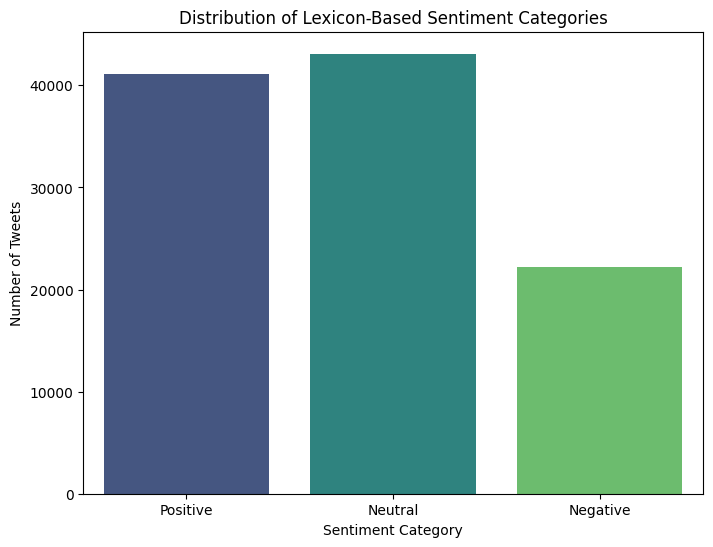

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='lexicon_sentiment', data=datatot, palette='viridis')
plt.title('Distribution of Lexicon-Based Sentiment Categories')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Tweets')
plt.show()

## Build the CNN Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import numpy as np

# 1. Prepare target labels (y)
# Convert sentiment categories to numerical labels
label_encoder = LabelEncoder()
datatot['sentiment_encoded'] = label_encoder.fit_transform(datatot['lexicon_sentiment'])

# One-hot encode the numerical labels
y = to_categorical(datatot['sentiment_encoded'])

# 2. Prepare input features (X)
X = np.array(datatot['padded_text'].tolist())

# 3. Split data into training and validation sets
# Using stratify to maintain the proportion of sentiment categories in both sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_val: {y_val.shape}")

# Model Parameters
vocabulary_size = len(tokenizer.word_index) + 1 # +1 for padding/0 index
embedding_dim = 128 # Dimension of the word embeddings
filters = 128 # Number of filters for the Conv1D layer
kernel_size = 5 # Size of the convolutional kernel
output_classes = y_train.shape[1] # Number of sentiment categories (e.g., 3 for Negative, Neutral, Positive)
input_length = max_sequence_length # Length of input sequences after padding

# Build the 1D CNN Model
model = Sequential([
    Embedding(input_dim=vocabulary_size, output_dim=embedding_dim, input_length=input_length),
    Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'),
    GlobalMaxPooling1D(), # Reduces output to 2D, suitable for Dense layers
    Dropout(0.5),
    Dense(units=32, activation='relu'),
    Dropout(0.5),
    Dense(units=output_classes, activation='softmax') # Softmax for multi-class classification
])

# Compile the Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Shape of X_train: (85084, 21)
Shape of y_train: (85084, 3)
Shape of X_val: (21271, 21)
Shape of y_val: (21271, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train the 1D CNN Model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define training parameters
batch_size = 32
epochs = 50 # EarlyStopping will handle when to stop

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor the validation loss
    patience=5,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True, # Restore model weights from the epoch with the best value of the monitored quantity
    verbose=1
)

# Train the model with EarlyStopping
history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping], # Add the callback here
    verbose=1
)

print("\nModel training complete (with Early Stopping).")

Epoch 1/50
2659/2659 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9266 - loss: 0.2027 - val_accuracy: 0.9709 - val_loss: 0.0853
Epoch 2/50
2659/2659 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9692 - loss: 0.0934 - val_accuracy: 0.9739 - val_loss: 0.0754
Epoch 3/50
2659/2659 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9744 - loss: 0.0752 - val_accuracy: 0.9777 - val_loss: 0.0689
Epoch 4/50
2659/2659 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9784 - loss: 0.0625 - val_accuracy: 0.9765 - val_loss: 0.0746
Epoch 5/50
2659/2659 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9811 - loss: 0.0570 - val_accuracy: 0.9788 - val_loss: 0.0655
Epoch 6/50
2659/2659 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9829 - loss: 0.0498 - val_accuracy: 0.9783 - val_loss: 0.0783
Epoch 7/50
2659/2659 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9849 - loss: 0.0455 - val_accuracy: 0.9797 - val_loss: 0.0802
Epoch 8/50
2659/2659 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9858 - loss: 0

## Plot Training and Validation Curves

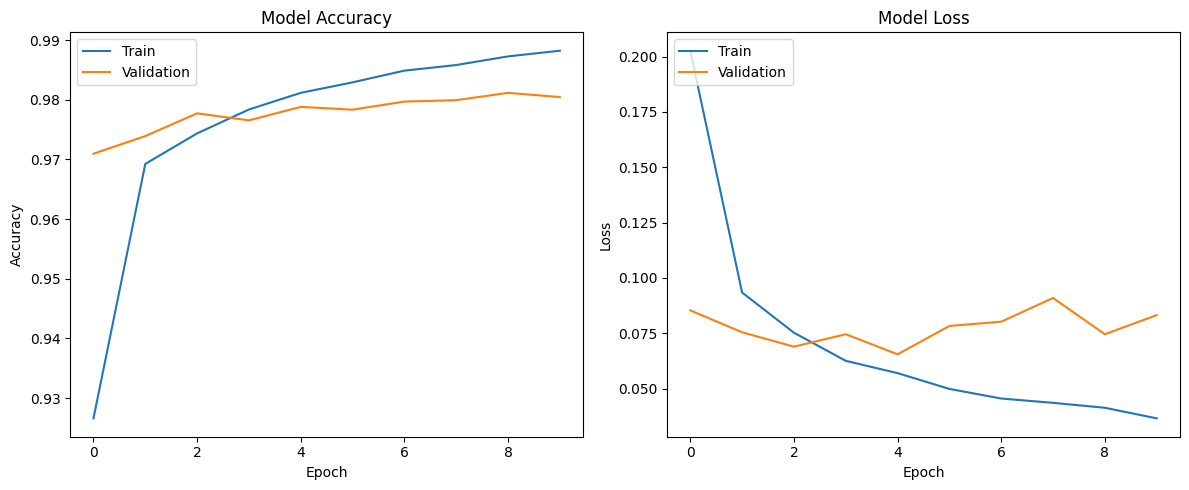

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

## Evaluate Model Performance

665/665 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


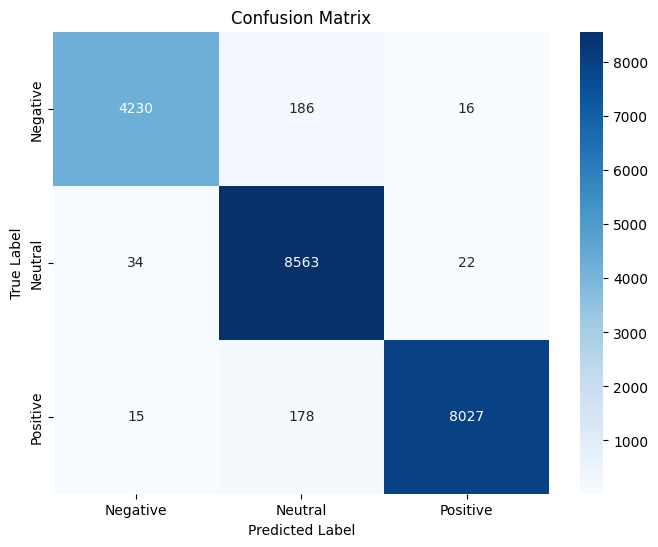


Classification Report:
              precision    recall  f1-score   support

    Negative       0.99      0.95      0.97      4432
     Neutral       0.96      0.99      0.98      8619
    Positive       1.00      0.98      0.99      8220

    accuracy                           0.98     21271
   macro avg       0.98      0.97      0.98     21271
weighted avg       0.98      0.98      0.98     21271



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Predict probabilities on the validation set
y_pred_proba = model.predict(X_val)

# Convert predicted probabilities to class labels
y_pred_labels = np.argmax(y_pred_proba, axis=1)

# Convert true one-hot encoded labels to class labels
y_true_labels = np.argmax(y_val, axis=1)

# Generate confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)

# Get class names from label_encoder (assuming label_encoder is still available from previous steps)
class_names = ['Negative', 'Neutral', 'Positive'] # Adjust if your label_encoder mapping is different

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Display classification report
print("\nClassification Report:")
print(classification_report(y_true_labels, y_pred_labels, target_names=class_names))


In [ ]:
from collections import Counter
import itertools

# Filter the DataFrame for neutral sentiment
neutral_sentences_df = datatot[datatot['lexicon_sentiment'] == 'Neutral']

# Extract the lemmatized text (which is a list of words for each sentence)
lemmatized_words_neutral = neutral_sentences_df['lemmatized_text'].tolist()

# Flatten the list of lists into a single list of all words
all_neutral_words = list(itertools.chain.from_iterable(lemmatized_words_neutral))

# Count the frequency of each word
word_counts = Counter(all_neutral_words)

# Display the 50 most common words
print("Top 50 most frequently used words in neutral sentences:")
for word, count in word_counts.most_common(50):
    print(f"'{word}': {count}")

Top 50 most frequently used words in neutral sentences:
'feel': 20525
'feeling': 10740
'im': 5263
'like': 2671
'time': 2432
'empty': 2404
'know': 2250
'get': 2123
'day': 1942
'comfortable': 1855
'really': 1798
'one': 1783
'want': 1768
'would': 1636
'people': 1614
'make': 1542
'thing': 1453
'go': 1443
'dont': 1400
'think': 1371
'going': 1365
'life': 1364
'little': 1346
'still': 1302
'even': 1271
'much': 1266
'way': 1204
'ive': 1203
'need': 1173
'back': 1133
'could': 1111
'work': 1103
'cant': 1043
'see': 1029
'something': 1029
'today': 959
'bit': 943
'u': 922
'say': 920
'got': 910
'friend': 897
'hated': 894
'home': 893
'right': 890
'whatever': 879
'hate': 834
'didnt': 803
'always': 801
'come': 801
'year': 795
